# Grid simulation with Pandapower and Simbench

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandapower as pp
import pandas as pd
import simbench as sb
from pandapower.control import ConstControl
from pandapower.timeseries import OutputWriter, run_timeseries

from src.load_profiles import get_load_profile

In [4]:
# Tip to automatically reload your own functions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Pandapower Basics

Pandapower is a library for calculation/simulation of power grids.
It uses pandas and [PYPOWER](https://github.com/rwl/PYPOWER) to enable network calculations.

* Website: http://www.pandapower.org/
* Documentation: https://pandapower.readthedocs.io/en/latest/about.html.
* Tutorials: https://nbviewer.org/github/e2nIEE/pandapower/tree/develop/tutorials/.


Convention for naming units: <parameter>_<unit> or <parameter>_<phase>_<unit>. Example: vn_kv -> $v_n[kV]$. More information in function docstring or documentation.

First, we build a minimal grid from individual components.

In [5]:
# create empty net
my_net = pp.create_empty_network()

In [6]:
my_net

This pandapower network is empty

In [7]:
# create buses
bus1 = pp.create_bus(my_net, vn_kv=20.0, name="Bus 1")
bus2 = pp.create_bus(my_net, vn_kv=0.4, name="Bus 2")
bus3 = pp.create_bus(my_net, vn_kv=0.4, name="Bus 3")

In [8]:
my_net.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 1,20.0,b,None,True,None
1,Bus 2,0.4,b,None,True,None
2,Bus 3,0.4,b,None,True,None


In [9]:
# The returned value is the index of the element in its table
print(type(bus1), bus1)

<class 'numpy.int64'> 0


In [10]:
# create bus elements
pp.create_ext_grid(
    my_net, bus=bus1, vm_pu=1.02, name="Grid Connection"
)  # creates external grid
pp.create_load(my_net, bus=bus3, p_mw=0.100, q_mvar=0.05, name="Load")  # creates load

np.int64(0)

In [11]:
# create branch elements
trafo = pp.create_transformer(
    my_net, hv_bus=bus1, lv_bus=bus2, std_type="0.4 MVA 20/0.4 kV", name="Trafo"
)
line = pp.create_line(
    my_net,
    from_bus=bus2,
    to_bus=bus3,
    length_km=0.1,
    std_type="NAYY 4x50 SE",
    name="Line",
)

In [12]:
my_net

This pandapower network includes the following parameter tables:
   - bus (3 elements)
   - load (1 element)
   - ext_grid (1 element)
   - line (1 element)
   - trafo (1 element)

In [13]:
my_net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable
0,Grid Connection,0,1.02,0.0,1.0,True,False


No or insufficient geodata available --> Creating artificial coordinates. This may take some time


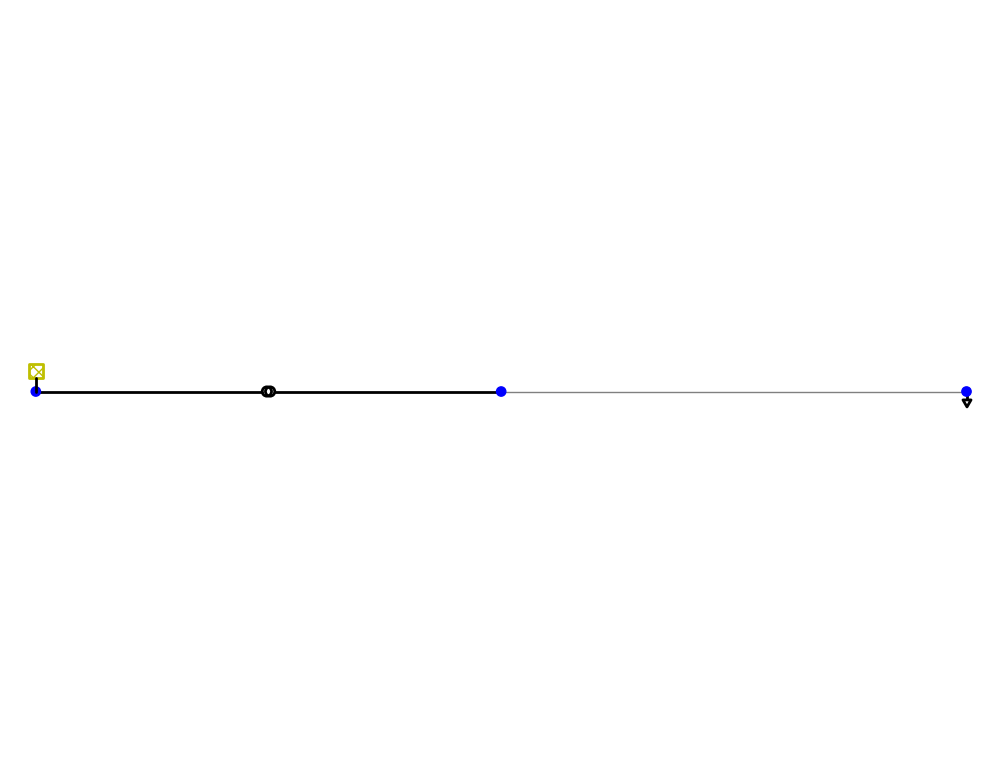

<Axes: >

In [14]:
pp.plotting.simple_plot(my_net, plot_loads=True, plot_gens=True, plot_sgens=True)

In [15]:
pp.runpp(my_net, numba=False)

In [16]:
my_net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.020000,0.000000,-0.107265,-0.052675
1,1.008843,-150.760126,0.000000,0.000000
2,0.964431,-149.884141,0.100000,0.050000


In [17]:
[el for el in dir(my_net) if el.startswith("res")]

['res_asymmetric_load',
 'res_asymmetric_load_3ph',
 'res_asymmetric_sgen',
 'res_asymmetric_sgen_3ph',
 'res_bus',
 'res_bus_3ph',
 'res_bus_dc',
 'res_bus_est',
 'res_bus_sc',
 'res_dcline',
 'res_ext_grid',
 'res_ext_grid_3ph',
 'res_ext_grid_sc',
 'res_gen',
 'res_gen_sc',
 'res_impedance',
 'res_impedance_est',
 'res_line',
 'res_line_3ph',
 'res_line_dc',
 'res_line_est',
 'res_line_sc',
 'res_load',
 'res_load_3ph',
 'res_load_dc',
 'res_motor',
 'res_sgen',
 'res_sgen_3ph',
 'res_sgen_sc',
 'res_shunt',
 'res_shunt_3ph',
 'res_shunt_est',
 'res_source_dc',
 'res_ssc',
 'res_storage',
 'res_storage_3ph',
 'res_svc',
 'res_switch',
 'res_switch_est',
 'res_switch_sc',
 'res_tcsc',
 'res_trafo',
 'res_trafo3w',
 'res_trafo3w_est',
 'res_trafo3w_sc',
 'res_trafo_3ph',
 'res_trafo_est',
 'res_trafo_sc',
 'res_vsc',
 'res_vsc_bipolar',
 'res_vsc_stacked',
 'res_ward',
 'res_xward']

In [18]:
# Unit descriptions in https://pandapower.readthedocs.io/en/latest/elements/line.html#result-parameters

my_net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,0.105392,0.050696,-0.1,-0.05,0.005392,0.000696,0.167325,0.167326,0.167326,1.008843,-150.760126,0.964431,-149.884141,117.835208


##  Example grids and simulation

### Simple Pandapower example grid

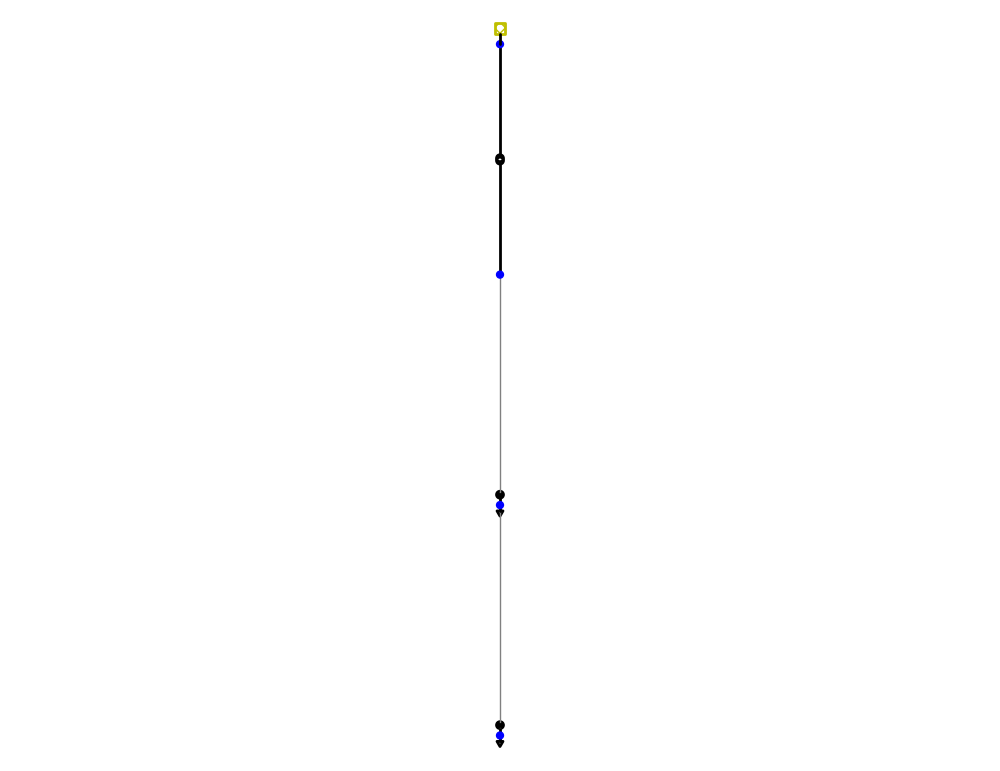

<Axes: >

In [19]:
# https://pandapower.readthedocs.io/en/latest/networks/test.html#pandapower.networks.simple_four_bus_system
small_net = pp.networks.simple_four_bus_system()
pp.plotting.simple_plot(small_net, plot_loads=True, plot_gens=True, plot_sgens=True)

In [20]:
small_net

This pandapower network includes the following parameter tables:
   - bus (4 elements)
   - load (2 elements)
   - sgen (2 elements)
   - ext_grid (1 element)
   - line (2 elements)
   - trafo (1 element)

In [21]:
small_net.load

,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type
0,load1,2,0.03,0.01,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
1,load2,3,0.03,0.01,0.0,0.0,0.0,0.0,NaN,1.0,True,wye


In [22]:
small_net.sgen

,name,bus,p_mw,q_mvar,min_q_mvar,max_q_mvar,sn_mva,scaling,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,in_service,type,current_source
0,pv1,2,0.020,0.005,NaN,NaN,0.03,1.0,False,<NA>,False,NaN,True,wye,True
1,pv2,3,0.015,0.002,NaN,NaN,0.02,1.0,False,<NA>,False,NaN,True,wye,True


### Time series calculation using pandapower

Basierend auf dem [Simple Time Series Example](https://github.com/e2nIEE/pandapower/blob/develop/tutorials/time_series.ipynb) Tutorial von pandapower, versuchen wir dieses simple Netz mit unseren vorher definierten Zeitreihen zu koppeln.
#Englisch:

In [23]:
# Step 1 net, already done

In [24]:
# Step 2, import datasources
pv = pd.read_csv("outputs/pv_example.csv", index_col=0)

In [25]:
lastprofile_file = Path("data") / "representative_profiles_vdew.xls"
assert (
    lastprofile_file.is_file()
), f"Did not find file with representative load profiles at {lastprofile_file}"

In [26]:
pv.index = pd.to_datetime(pv.index)
pv = pv / 10**3

In [27]:
# H0 at the moment has non-matching timezone and exploding values in the end of year!
h0profile = get_load_profile(
    lastprofile_file,
    from_=pv.index[0],
    to=pv.index[-1],
    type="H0",
)

In [28]:
h0profile = h0profile.resample("h").mean() / 10**6 * 5

In [29]:
df = pd.DataFrame({"PV": pv.squeeze(), "H0": h0profile.squeeze()})
df.head()

,PV,H0
2015-01-01 00:00:00,-0.0001,0.000504
2015-01-01 01:00:00,-0.0001,0.000379
2015-01-01 02:00:00,-0.0001,0.000290
2015-01-01 03:00:00,-0.0001,0.000261
2015-01-01 04:00:00,-0.0001,0.000243


<Axes: >

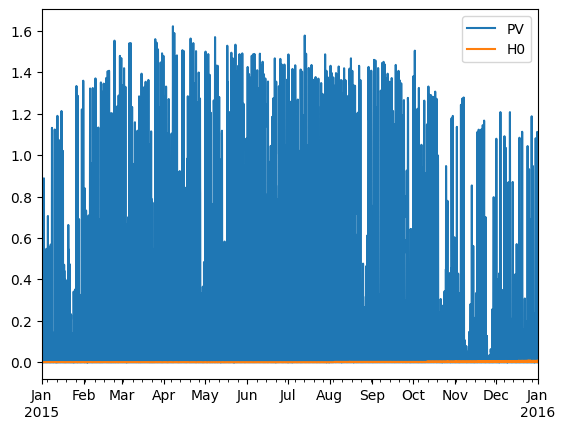

In [30]:
df.plot()

In [31]:
small_net.sgen

,name,bus,p_mw,q_mvar,min_q_mvar,max_q_mvar,sn_mva,scaling,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,in_service,type,current_source
0,pv1,2,0.020,0.005,NaN,NaN,0.03,1.0,False,<NA>,False,NaN,True,wye,True
1,pv2,3,0.015,0.002,NaN,NaN,0.02,1.0,False,<NA>,False,NaN,True,wye,True


In [32]:
# Step 3: Create Controllers, attach to network
ConstControl(
    small_net,
    element="load",
    variable="p_mw",
    element_index=[0, 1],
    data_source=df,
    profile_name=["H0", "H0"],
)

This ConstControl has the following parameters: 

index:             0
json_excludes:     ['self', '__class__']

In [33]:
ConstControl(
    small_net,
    element="sgen",
    variable="p_mw",
    element_index=[0, 1],
    data_source=df,
    profile_name=["PV", "PV"],
)

This ConstControl has the following parameters: 

index:             1
json_excludes:     ['self', '__class__']

In [34]:
# Step 4: Create Output Writer, copy from nb
output_dir = Path("outputs") / "small_net"
if not output_dir.exists():
    output_dir.mkdir()

ow = OutputWriter(
    small_net,
    df.index,
    output_path=output_dir,
    output_file_type=".json",
    log_variables=list(),
)
# these variables are saved to the harddisk after / during the time series loop
ow.log_variable("res_load", "p_mw")
ow.log_variable("res_bus", "vm_pu")
ow.log_variable("res_line", "loading_percent")
ow.log_variable("res_line", "i_ka")

In [35]:
output_dir.exists()

True

In [36]:
df.index.to_list()[0]

Timestamp('2015-01-01 00:00:00')

In [37]:
?run_timeseries

In [39]:
# Step 5: run timeseries
run_timeseries(small_net, df.index.to_list(), numba=True)

# This has a problem at the moment, probably due to inconsistent data / types
# Below example does work


  0%|          | 0/8761 [00:00<?, ?it/s]

AttributeError: 'DataFrame' object has no attribute 'get_time_step_value'

### Example grid from Simbench including example time series

Simbench offers many example grids for various scenarios: https://simbench.de/de/datensaetze/.
(Link doesn't work with Firefox?).

This example notebook gives a good overview of the possible uses of the networks together with pandapower:
https://github.com/e2nIEE/simbench/blob/master/tutorials/simbench_grids_basics_and_usage.ipynb.

In [40]:
# simbench - simbench.de - time series of consumption/feed-in data + grids.
sb_code_lv = "1-LV-semiurb4--0-sw"

# creating a standard lv test network
net = sb.get_simbench_net(sb_code_lv)

  0%|          | 1/8761 [01:14<180:18:49, 74.10s/it]
C:\Users\z004uh1h\Documents\FHTW\panda_power\fh-pandapower-cosimulation\.venv\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
C:\Users\z004uh1h\Documents\FHTW\panda_power\fh-pandapower-cosimulation\.venv\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
 

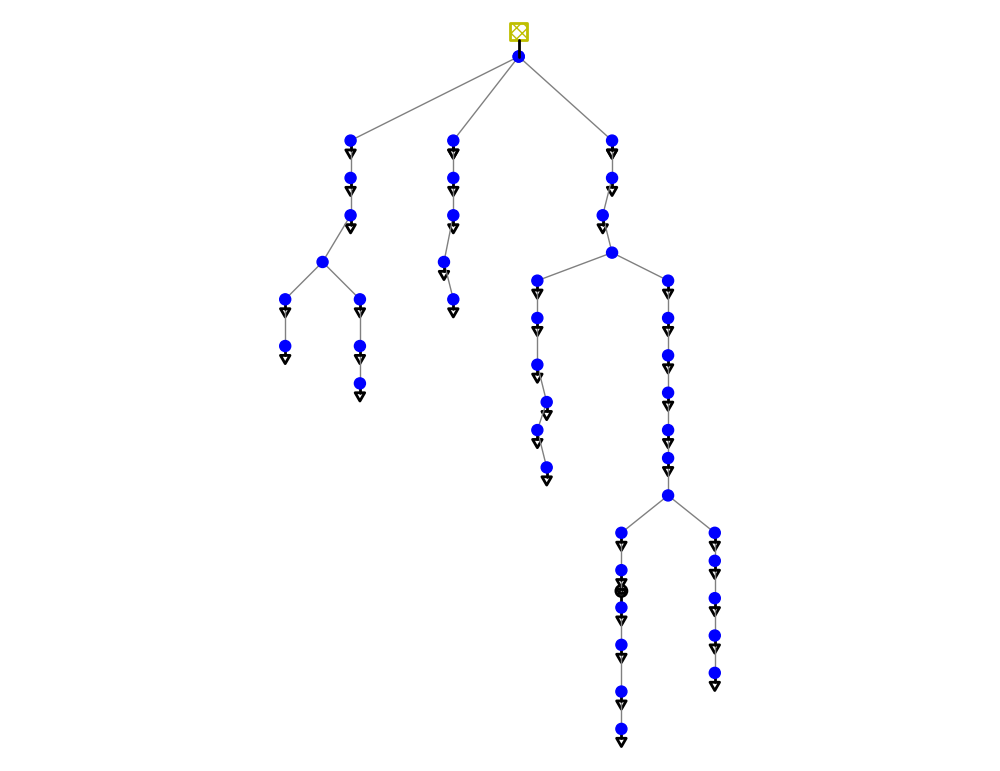

<Axes: >

In [41]:
pp.plotting.simple_plot(net, plot_loads=True, plot_gens=True, plot_sgens=True)

In [42]:
for key, df in net.profiles.items():
    print(f"{key}: {list(df.columns)}\n")

load: ['time', 'G1-A_qload', 'G1-A_pload', 'G1-C_qload', 'G1-C_pload', 'G2-A_qload', 'G2-A_pload', 'G4-A_qload', 'G4-A_pload', 'G4-B_qload', 'G4-B_pload', 'G6-A_qload', 'G6-A_pload', 'H0-A_qload', 'H0-A_pload', 'H0-B_qload', 'H0-B_pload', 'H0-G_qload', 'H0-G_pload', 'H0-L_qload', 'H0-L_pload']

powerplants: ['time']

renewables: ['time', 'PV5']

storage: ['time']



In [43]:
# Get PV data from simbench
pv = net.profiles["renewables"].copy()
pv.head()

,time,PV5
0,01.01.2016 00:00,0.0
1,01.01.2016 00:15,0.0
2,01.01.2016 00:30,0.0
3,01.01.2016 00:45,0.0
4,01.01.2016 01:00,0.0


In [44]:
# Make time the index, dayfirst for day.month.year and sort_index to allow slicing
pv.index = pd.to_datetime(pv["time"], dayfirst=True)
pv = pv["PV5"].sort_index()
pv.tail()

time
2016-12-31 22:45:00    0.0
2016-12-31 23:00:00    0.0
2016-12-31 23:15:00    0.0
2016-12-31 23:30:00    0.0
2016-12-31 23:45:00    0.0
Name: PV5, dtype: float64

<Axes: xlabel='time'>

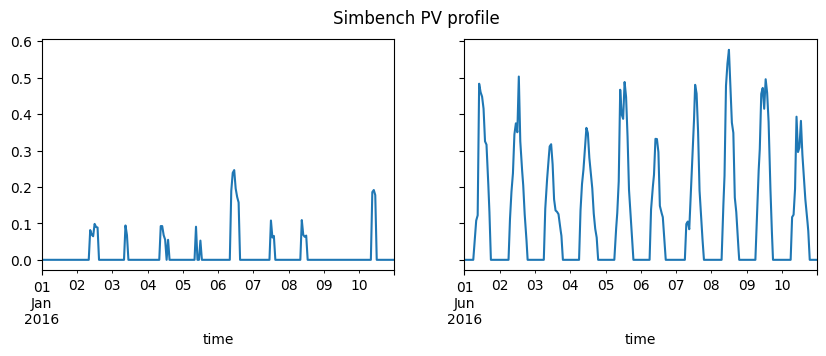

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
fig.suptitle("Simbench PV profile")
pv["2016-01-01":"2016-01-10"].plot(ax=axs[0])
pv["2016-06-01":"2016-06-10"].plot(ax=axs[1])

In [46]:
h0A = net.profiles["load"].set_index("time")["H0-A_pload"].copy()
h0A.index = pd.to_datetime(h0A.index, dayfirst=True)
h0A = h0A.sort_index()

<Axes: xlabel='time'>

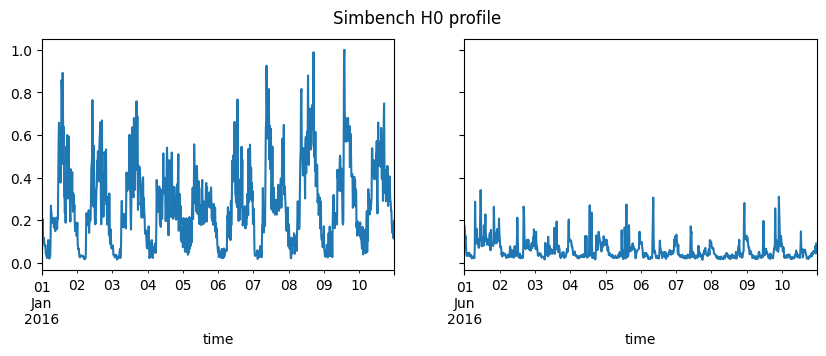

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
fig.suptitle("Simbench H0 profile")
h0A["2016-01-01":"2016-01-10"].plot(ax=axs[0])
h0A["2016-06-01":"2016-06-10"].plot(ax=axs[1])

### Run timeseries analysis with predefined profiles

After [tutorial](https://github.com/e2nIEE/simbench/blob/master/tutorials/simbench_grids_basics_and_usage.ipynb).

In [48]:
# Check that all profiles exist
assert not sb.profiles_are_missing(net)

In [49]:
profiles = sb.get_absolute_values(net, profiles_instead_of_study_cases=True)

In [50]:
# Apply ConstControllers
sb.apply_const_controllers(net, profiles)
# Define time steps for 1 day
time_steps = range(0, 96)

In [51]:
# Create Output writer
output_dir = Path("./outputs")
output_dir.mkdir(exist_ok=True)
output_dir = output_dir / "simbench_ts_run"
# Using json here, as csv has non standard formatting, could also use .xls
#Englisch: Using json here, as csv has non-standard formatting, could also use .xls
ow = OutputWriter(net, time_steps, output_path=output_dir, output_file_type=".json")
ow.log_variable("res_load", "p_mw", eval_function=np.sum, eval_name="Load Sum")
ow.log_variable("res_bus", "vm_pu", eval_function=np.min, eval_name="min_vm_pu")
ow.log_variable("res_bus", "vm_pu", eval_function=np.max, eval_name="max_vm_pu")

In [52]:
run_timeseries(net, time_steps, numba=False)

  0%|          | 0/96 [00:00<?, ?it/s]C:\Users\z004uh1h\Documents\FHTW\panda_power\fh-pandapower-cosimulation\.venv\Lib\site-packages\pandapower\pypower\dSbus_dV.py:34: RuntimeWarning: invalid value encountered in divide
  diagVnorm = sparse((V / abs(V), (ib, ib)))
C:\Users\z004uh1h\Documents\FHTW\panda_power\fh-pandapower-cosimulation\.venv\Lib\site-packages\pandapower\pypower\newtonpf.py:512: MatrixRankWarning: Matrix is exactly singular
  dx = -1 * spsolve(J, F, permc_spec=permc_spec, use_umfpack=use_umfpack)
CalculationNotConverged at time step 0


LoadflowNotConverged: 

In [53]:
# Read Results and create DataFrame
vm_pu_file = output_dir / "res_bus" / "vm_pu.json"
vm_pu = pd.read_json(vm_pu_file)
ll_file = output_dir / "res_line" / "loading_percent.json"
line_loading = pd.read_json(ll_file)
load_p_file = output_dir / "res_load" / "p_mw.json"
load_p = pd.read_json(load_p_file)

FileNotFoundError: File outputs\simbench_ts_run\res_bus\vm_pu.json does not exist

  1%|          | 1/96 [00:16<26:46, 16.91s/it]


In [54]:
# Plot line loading
vm_pu[["min_vm_pu", "max_vm_pu"]].plot()
plt.xlabel("time step")
plt.ylabel("voltage mag. [p.u.]")
plt.title("Voltage Magnitude")
plt.grid()

NameError: name 'vm_pu' is not defined

In [ ]:
# load results
load_p.sort_index().plot()
plt.xlabel("time step")
plt.ylabel("P [MW]")
plt.title("Sum of Loads")
plt.grid()
plt.show()